# Solute transport: mPCN vs pCN convergence

Generate a shared-draws solute-transport dataset and compare mPCN and pCN chains for convergence.
Chains are cached under estimations/solute_transport/... and figures are written to reports/solute_transport/... so reruns reuse existing chains.

In [1]:
import os
import sys
from pathlib import Path
import json
import hashlib
import time

import numpy as np
import matplotlib.pyplot as plt

def _resolve_repo_root():
    env_root = os.environ.get("MULTIPROPOSAL_RUN_ROOT")
    if env_root:
        return Path(env_root).expanduser().resolve()
    root = Path.cwd().resolve()
    while root != root.parent and not (root / "pyproject.toml").exists():
        root = root.parent
    return root

repo_root = _resolve_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from multiproposal.problems.advection_diffusion import (
    make_omegas_power,
    make_Astar_nn,
    make_Astar_from_atrue,
    params_from_skew,
    prior_diag_from_powerlaw,
    solve_theta,
 )
from multiproposal.problems.advection_diffusion import AdvectionDiffusionToy
from multiproposal.algorithms.mpcn import mpcn_chain
from multiproposal.algorithms.pcn import pcn_chain
from multiproposal.utils.run_paths import format_float_tag
from multiproposal.plotting.figure_style import apply_pub_style

In [2]:
# Solute transport configuration
seed_data = 0
seed_mcmc = 202

# Select among predefined configurations (extend as needed)
config_id = 2  # 1=small, 2=medium, 3=extra_large, 4=baseline

configurations = {
    1: {"d": 20, "obs_highest_freq": 8, "obs_bandwidth": 5},
    2: {"d": 40, "obs_highest_freq": 12, "obs_bandwidth": 7},
    3: {"d": 60, "obs_highest_freq": 16, "obs_bandwidth": 9},
    4: {"d": 40, "obs_highest_freq": 8, "obs_bandwidth": 5},
}
if config_id not in configurations:
    raise ValueError(f"Unknown config_id: {config_id}")

selected_config = configurations[config_id]
d = selected_config["d"]
obs_highest_freq = selected_config["obs_highest_freq"]
obs_bandwidth = selected_config["obs_bandwidth"]

kappa = 0.02
sigma = 0.5
alpha = 3.0
gamma = 2.0
tau2 = 2.0
a_mode = 'nearest_neighbor'
use_prior_A = True
shared_draws_seed = seed_data
obs_config = 'central_modes'

print('config_id:', config_id)
print('d:', d)
print('kappa:', kappa)
print('sigma:', sigma)
print('obs_config:', obs_config)

config_id: 2
d: 40
kappa: 0.02
sigma: 0.5
obs_config: central_modes


In [3]:
# Configuration is defined in the previous cell.
pass

In [4]:
if isinstance(obs_config, dict):
    obs_config_serializable = {
        key: (val.tolist() if isinstance(val, np.ndarray) else val)
        for key, val in obs_config.items()
    }
else:
    obs_config_serializable = obs_config

data_id_config = {
    'seed_data': seed_data,
    'kappa': kappa,
    'sigma': sigma,
    'alpha': alpha,
    'gamma': gamma,
    'tau2': tau2,
    'a_mode': a_mode,
    'use_prior_A': use_prior_A,
    'shared_draws_seed': shared_draws_seed,
    'obs_highest_freq': obs_highest_freq,
    'obs_bandwidth': obs_bandwidth,
    'obs_config': obs_config_serializable,
    'd': d,
}
data_config = dict(data_id_config)
data_config

{'seed_data': 0,
 'kappa': 0.02,
 'sigma': 0.5,
 'alpha': 3.0,
 'gamma': 2.0,
 'tau2': 2.0,
 'a_mode': 'nearest_neighbor',
 'use_prior_A': True,
 'shared_draws_seed': 0,
 'obs_highest_freq': 12,
 'obs_bandwidth': 7,
 'obs_config': 'central_modes',
 'd': 40}

In [5]:
def _canonicalize_payload(obj):
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, dict):
        return {key: _canonicalize_payload(val) for key, val in sorted(obj.items())}
    if isinstance(obj, (list, tuple)):
        return [_canonicalize_payload(val) for val in obj]
    return obj

def _stable_hash(payload, length=12):
    data = json.dumps(
        _canonicalize_payload(payload),
        sort_keys=True,
        separators=(",", ":"),
        ensure_ascii=True,
    ).encode("utf-8")
    return hashlib.sha256(data).hexdigest()[:length]

In [6]:
# Shared-draws helpers
def get_obs_indices(dim_value, highest_freq, bandwidth):
    highest_freq = min(highest_freq, dim_value)
    bandwidth = min(bandwidth, dim_value)
    start = max(0, highest_freq - bandwidth + 1)
    return np.arange(start, highest_freq + 1, dtype=int)

def get_param_indices_for_dim(dim, shared_draws):
    cache = shared_draws.setdefault('param_indices_cache', {})
    if dim not in cache:
        iju = shared_draws['param_iju']
        mask = (iju[0] < dim) & (iju[1] < dim)
        cache[dim] = np.nonzero(mask)[0]
    return cache[dim]

def build_shared_draws(
    d_max,
    kappa,
    sigma,
    alpha,
    gamma,
    tau2,
    offset,
    a_mode,
    seed,
):
    rng = np.random.default_rng(seed)
    m_max = d_max * (d_max - 1) // 2
    prior_diag_max = prior_diag_from_powerlaw(
        d_max, alpha=alpha, gamma=gamma, tau2=tau2, offset=offset
    )
    if prior_diag_max.shape != (m_max,):
        raise ValueError(
            f'prior_diag_max must have shape ({m_max},), got {prior_diag_max.shape}'
        )
    if a_mode == 'nearest_neighbor':
        omegas = make_omegas_power(
            d_max, beta=alpha, c=2.0 ** (-gamma), offset=offset
        )
        A_true_max = make_Astar_nn(d_max, omegas)
        a_true_max = params_from_skew(A_true_max)
    elif a_mode == 'prior':
        z_prior = rng.standard_normal(m_max)
        a_true_max = z_prior * np.sqrt(prior_diag_max)
        A_true_max = make_Astar_from_atrue(d_max, a_true_max)
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    g_max = np.zeros(d_max, dtype=float)
    g_max[0] = 1.0
    theta_true_max = solve_theta(d_max, a_true_max, g_max, kappa)
    noise_max = rng.standard_normal(d_max)
    z_init = rng.standard_normal(m_max)
    a_init_max = z_init * np.sqrt(prior_diag_max)
    return {
        'd_max': d_max,
        'm_max': m_max,
        'kappa': kappa,
        'sigma': sigma,
        'alpha': alpha,
        'gamma': gamma,
        'tau2': tau2,
        'offset': offset,
        'a_mode': a_mode,
        'param_iju': np.triu_indices(d_max, k=1),
        'param_indices_cache': {},
        'prior_diag': prior_diag_max,
        'a_true': a_true_max,
        'A_true': A_true_max,
        'g': g_max,
        'theta_true': theta_true_max,
        'noise': noise_max,
        'a_init': a_init_max,
    }

def generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws):
    a_mode_local = shared_draws['a_mode']
    param_idx = get_param_indices_for_dim(dim, shared_draws)
    prior_diag = shared_draws['prior_diag'][param_idx]
    g = shared_draws['g'][:dim]
    if a_mode_local == 'nearest_neighbor':
        omegas = make_omegas_power(
            dim,
            beta=shared_draws['alpha'],
            c=2.0 ** (-shared_draws['gamma']),
            offset=shared_draws['offset'],
        )
        A_true = make_Astar_nn(dim, omegas)
        a_true = params_from_skew(A_true)
        theta_true = solve_theta(dim, a_true, g, shared_draws['kappa'])
    elif a_mode_local == 'prior':
        a_true = shared_draws['a_true'][param_idx]
        A_true = make_Astar_from_atrue(dim, a_true)
        theta_true = shared_draws['theta_true'][:dim]
    else:
        raise ValueError("a_mode must be 'nearest_neighbor' or 'prior'")
    noise = shared_draws['noise'][:dim]
    y = theta_true[obs_indices] + shared_draws['sigma'] * noise[obs_indices]
    a_init = shared_draws['a_init'][param_idx]
    return {
        'dim': dim,
        'kappa': shared_draws['kappa'],
        'alpha': shared_draws['alpha'],
        'gamma': shared_draws['gamma'],
        'tau2': shared_draws['tau2'],
        'sigma': shared_draws['sigma'],
        'obs_indices': obs_indices,
        'prior_diag': prior_diag,
        'a_true': a_true,
        'A_true': A_true,
        'g': g,
        'theta_true': theta_true,
        'y': y,
        'a_init': a_init,
    }

def build_problem_for_dim(dim, shared_draws):
    obs_indices = get_obs_indices(dim, obs_highest_freq, obs_bandwidth)
    data = generate_advection_diffusion_data_shared(dim, obs_indices, shared_draws)
    problem = AdvectionDiffusionToy(
        dim=dim,
        kappa=kappa,
        sigma=sigma,
        y=data['y'],
        obs_indices=obs_indices,
        g=data['g'],
        prior_diag=data['prior_diag'],
    )
    return problem, data['a_init'], data

In [7]:
shared_draws = build_shared_draws(
    d_max=d,
    kappa=kappa,
    sigma=sigma,
    alpha=alpha,
    gamma=gamma,
    tau2=tau2,
    offset=1.0,
    a_mode='prior' if use_prior_A else a_mode,
    seed=shared_draws_seed,
)
problem, a_init, data = build_problem_for_dim(d, shared_draws)
prior_diag = data['prior_diag']

print('Shared draws ready with d:', d)
print('Parameter dim:', problem.dim)
print('Initial x0 norm:', np.linalg.norm(a_init))

Shared draws ready with d: 40
Parameter dim: 780
Initial x0 norm: 0.33344310180534587


In [8]:
# MCMC configuration
n_iters = 1000
rho = 0.9
P = 100
num_pcn_chains = 20
num_mpcn_chains = 20
burn_in = 0

load_only = False

print('n_iters:', n_iters)
print('rho:', rho)
print('P:', P)
print('num_pcn_chains:', num_pcn_chains)
print('num_mpcn_chains:', num_mpcn_chains)
print('load_only:', load_only)

n_iters: 1000
rho: 0.9
P: 100
num_pcn_chains: 20
num_mpcn_chains: 20
load_only: False


In [10]:
run_config = {
    'dataset': 'solute_transport',
    'algorithm': 'mpcn_pcn_convergence',
    'data': data_config,
    'algorithm_config': {
        'n_iters': n_iters,
        'rho': rho,
        'P': P,
        'seed_mcmc': seed_mcmc,
        'burn_in': burn_in,
        'config_id': config_id,
    },
    'execution_config': {
        'num_pcn_chains': num_pcn_chains,
        'num_mpcn_chains': num_mpcn_chains,
    },
}
# Leave overrides as None to ensure new data/run folders per config.
data_id_override = None
run_id_override = None

run_id_config = dict(run_config['algorithm_config'])
data_id = data_id_override or f"data_h{_stable_hash(data_id_config)}"
run_id = run_id_override or f"mpcn_pcn_convergence_h{_stable_hash(run_id_config)}"

estimations_dir = repo_root / 'estimations' / 'solute_transport' / data_id / 'fixed' / run_id
reports_dir = repo_root / 'reports' / 'solute_transport' / data_id / 'fixed' / run_id
estimations_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

config_path = estimations_dir / 'config.json'
if not config_path.exists():
    payload = dict(run_config)
    payload['data_id'] = data_id
    payload['run_id'] = run_id
    with open(config_path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

print('data_id:', data_id)
print('run_id:', run_id)
print('Run directory:', estimations_dir)

data_id: data_h4afe80f670cc
run_id: mpcn_pcn_convergence_h0b2736f095a9
Run directory: /home/senng/multiproposal-internal/estimations/solute_transport/data_h4afe80f670cc/fixed/mpcn_pcn_convergence_h0b2736f095a9


In [11]:
rho_tag = format_float_tag(rho)
pcn_chains_dir = estimations_dir / 'chains' / 'independent_chains'
mpcn_chains_dir = estimations_dir / 'chains' / 'mpcn_independent'
pcn_chains_dir.mkdir(parents=True, exist_ok=True)
mpcn_chains_dir.mkdir(parents=True, exist_ok=True)

def pcn_chain_path(chain_idx):
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_chain{chain_idx:03d}.npz'

def pcn_index_path():
    return pcn_chains_dir / f'pcn_independent_rho{rho_tag}_seed{seed_mcmc}_index.json'

def mpcn_chain_path(chain_idx, seed):
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed}_chain{chain_idx:03d}.npz'

def mpcn_index_path():
    return mpcn_chains_dir / f'mpcn_P{P}_rho{rho_tag}_seed{seed_mcmc}_index.json'

def save_index(path, payload):
    with open(path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2)

def load_index(path, expected_meta=None):
    if not path.exists():
        return None
    with open(path, 'r', encoding='utf-8') as handle:
        payload = json.load(handle)
    if expected_meta is None:
        return payload
    meta = payload.get('metadata', {})
    for key, value in expected_meta.items():
        if meta.get(key) != value:
            return None
    return payload

def save_chain(path, chain, accept_rate, runtime_sec, extra=None):
    payload = {
        'chain': chain,
        'accept_rate': np.nan if accept_rate is None else float(accept_rate),
        'runtime_sec': float(runtime_sec),
    }
    if extra:
        payload.update(extra)
    np.savez_compressed(path, **payload)

def load_chain(path):
    if not path.exists():
        return None
    data = np.load(path, allow_pickle=True)
    chain = data['chain']
    accept_rate = float(data['accept_rate']) if 'accept_rate' in data else np.nan
    if np.isnan(accept_rate):
        accept_rate = None
    runtime_sec = float(data['runtime_sec']) if 'runtime_sec' in data else 0.0
    return chain, accept_rate, runtime_sec

In [12]:
def sample_prior_points(rng, prior_diag, count):
    z = rng.standard_normal((count, prior_diag.shape[0]))
    return z * np.sqrt(prior_diag)[None, :]

rng_starts = np.random.default_rng(seed_mcmc)
max_num_chains = 2000
all_start_points = sample_prior_points(rng_starts, prior_diag, max_num_chains)

pcn_start_points = all_start_points[:num_pcn_chains]
mpcn_start_points = all_start_points[:num_mpcn_chains]
mpcn_start_indices = np.arange(num_mpcn_chains, dtype=int)

print(f'Selected {num_mpcn_chains} mPCN start points:\n', mpcn_start_points[:, :3])
print(f'Selected {num_pcn_chains} PCN start points:\n', pcn_start_points[:, :3])

Selected 20 mPCN start points:
 [[ 0.45293009 -0.06614108 -0.04797837]
 [ 0.05901243  0.04540717  0.04969571]
 [-0.29020998  0.07762135  0.06598099]
 [-0.43561181  0.17315623  0.10486417]
 [ 0.05942926  0.025684   -0.00278945]
 [-0.33714309  0.07370772 -0.03060217]
 [-0.31460888 -0.16509775 -0.01913444]
 [ 0.15102337  0.01732577  0.02545787]
 [-0.04907562 -0.05528629 -0.02809041]
 [ 0.20628807 -0.00922339  0.00055469]
 [-0.41354851  0.05640402  0.04817323]
 [ 0.43234888 -0.05630487 -0.02285735]
 [ 0.20387215 -0.06879261 -0.01450386]
 [ 0.11383945 -0.0933477   0.04661752]
 [-0.20027974  0.02453208  0.00791474]
 [-0.11612728  0.03499104  0.01471201]
 [ 0.11616088 -0.07430608  0.0018243 ]
 [ 0.17744456  0.06695946 -0.03720851]
 [ 0.06584696  0.21930348 -0.02335057]
 [-0.36479887  0.28698796  0.00262407]]
Selected 20 PCN start points:
 [[ 0.45293009 -0.06614108 -0.04797837]
 [ 0.05901243  0.04540717  0.04969571]
 [-0.29020998  0.07762135  0.06598099]
 [-0.43561181  0.17315623  0.10486417]


In [13]:
pcn_expected_meta = {
    'rho': float(rho),
    'seed_mcmc': int(seed_mcmc),
    'n_iters': int(n_iters),
    'data_id': data_id,
    'run_id': run_id,
}
pcn_index_payload = load_index(pcn_index_path(), expected_meta=pcn_expected_meta)
pcn_chains = []
pcn_accept_rates = []
pcn_runtimes = []
pcn_loaded_count = 0
pcn_generated_count = 0

if pcn_index_payload is None:
    pcn_index_payload = {
        'metadata': dict(pcn_expected_meta),
        'chains': [],
    }
pcn_index_payload.setdefault('metadata', {}).update({
    **pcn_expected_meta,
    'count_requested': int(num_pcn_chains),
})

for chain_idx in range(num_pcn_chains):
    chain_path = pcn_chain_path(chain_idx)
    loaded = load_chain(chain_path)
    if loaded is None:
        if load_only:
            raise FileNotFoundError(f'Missing pCN chain: {chain_path}')
        rng = np.random.default_rng(seed_mcmc + 2000 + chain_idx)
        t0 = time.perf_counter()
        chain, acc_rate = pcn_chain(
            pcn_start_points[chain_idx],
            problem,
            rng,
            n_iters,
            rho=rho,
            return_acceptance=True,
        )
        runtime_sec = time.perf_counter() - t0
        save_chain(
            chain_path,
            chain,
            acc_rate,
            runtime_sec,
            extra={'start_index': int(chain_idx)},
        )
        loaded = (chain, acc_rate, runtime_sec)
        pcn_generated_count += 1
    else:
        pcn_loaded_count += 1
    chain, acc_rate, runtime_sec = loaded
    pcn_chains.append(chain)
    pcn_accept_rates.append(acc_rate)
    pcn_runtimes.append(runtime_sec)

pcn_index_payload['chains'] = [
    {
        'chain_idx': int(i),
        'file': pcn_chain_path(i).name,
        'seed': int(seed_mcmc + 2000 + i),
        'start_index': int(i),
    }
    for i in range(num_pcn_chains)
 ]
save_index(pcn_index_path(), pcn_index_payload)

print(
    f'pCN chains: {len(pcn_chains)} '
    f'(loaded {pcn_loaded_count}, generated {pcn_generated_count})'
 )

pCN chains: 20 (loaded 10, generated 10)


In [17]:
mpcn_expected_meta = {
    'rho': float(rho),
    'P': int(P),
    'seed_mcmc': int(seed_mcmc),
    'n_iters': int(n_iters),
    'data_id': data_id,
    'run_id': run_id,
}
mpcn_index_payload = load_index(mpcn_index_path(), expected_meta=mpcn_expected_meta)
mpcn_chains = []
mpcn_accept_rates = []
mpcn_runtimes = []
mpcn_loaded_count = 0
mpcn_generated_count = 0

if mpcn_index_payload is None:
    mpcn_index_payload = {
        'metadata': dict(mpcn_expected_meta),
        'chains': [],
    }
mpcn_index_payload.setdefault('metadata', {}).update({
    **mpcn_expected_meta,
    'count_requested': int(num_mpcn_chains),
})

for chain_idx, start_point in enumerate(mpcn_start_points):
    seed = seed_mcmc + 5000 + chain_idx
    chain_path = mpcn_chain_path(chain_idx, seed)
    loaded = load_chain(chain_path)
    if loaded is None:
        if load_only:
            raise FileNotFoundError(f'Missing mPCN chain: {chain_path}')
        rng = np.random.default_rng(seed)
        t0 = time.perf_counter()
        chain, accepted_index = mpcn_chain(
            start_point,
            problem,
            rng,
            n_iters,
            rho=rho,
            n_props=P,
            return_indices=True,
            n_jobs=1,
            parallel_backend='auto',
            parallelize_props=False,
            llh_chunk_size=0,
        )
        runtime_sec = time.perf_counter() - t0
        acc_rate = float(np.mean(accepted_index != 0))
        save_chain(
            chain_path,
            chain,
            acc_rate,
            runtime_sec,
            extra={'start_index': int(chain_idx)},
        )
        loaded = (chain, acc_rate, runtime_sec)
        mpcn_generated_count += 1
    else:
        mpcn_loaded_count += 1
    chain, acc_rate, runtime_sec = loaded
    mpcn_chains.append(chain)
    mpcn_accept_rates.append(acc_rate)
    mpcn_runtimes.append(runtime_sec)

mpcn_index_payload['chains'] = [
    {
        'chain_idx': int(i),
        'file': mpcn_chain_path(i, seed_mcmc + 5000 + i).name,
        'seed': int(seed_mcmc + 5000 + i),
        'start_index': int(i),
    }
    for i in range(num_mpcn_chains)
 ]
save_index(mpcn_index_path(), mpcn_index_payload)

print(
    f'mPCN chains: {len(mpcn_chains)} '
    f'(loaded {mpcn_loaded_count}, generated {mpcn_generated_count})'
 )

mPCN chains: 20 (loaded 20, generated 0)


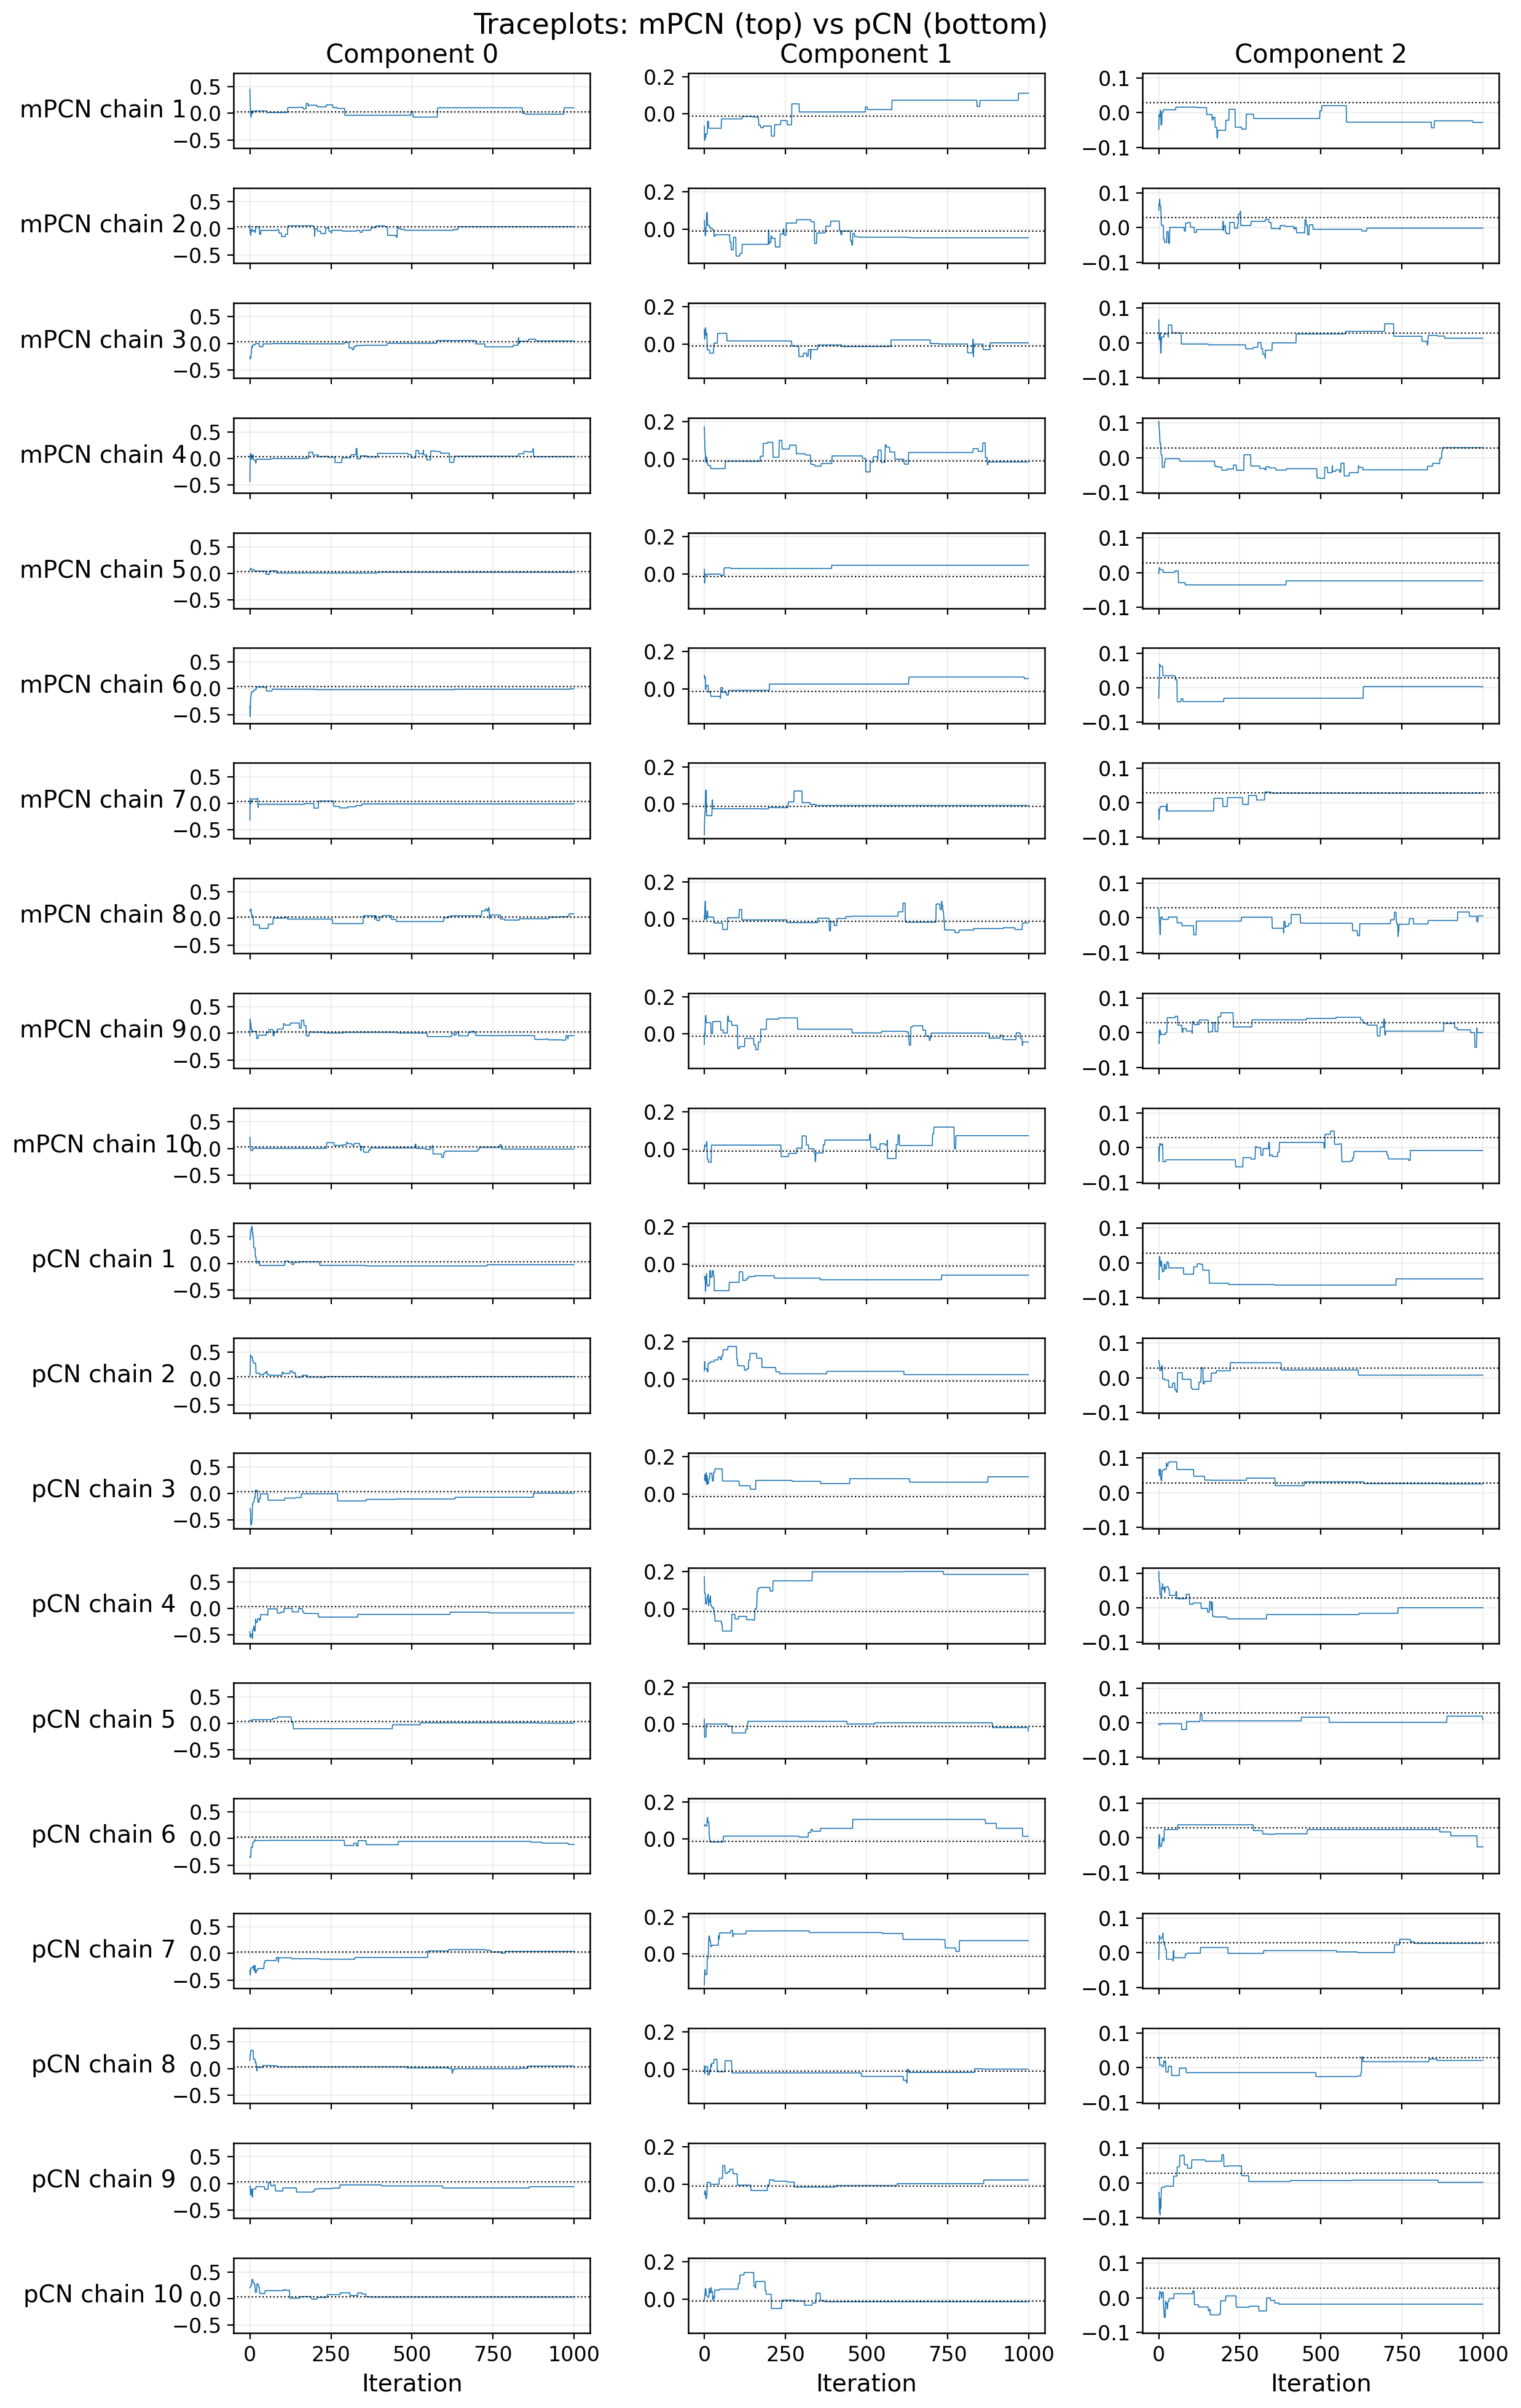

In [15]:
# Traceplots: mPCN (top) vs pCN (bottom) for first 3 parameters
apply_pub_style()

comp_list = [0, 1, 2]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 1:
    raise ValueError('Need at least one component for traceplots.')

plot_n = min(n_iters, 1000)
mpcn_plot_count = 10
pcn_plot_count = 10
row_height = 1.0

mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

mpcn_plot_indices = list(range(mpcn_plot_count))
pcn_pick_indices = list(mpcn_start_indices)[:pcn_plot_count]
if len(pcn_pick_indices) < pcn_plot_count:
    pcn_pick_indices = list(range(pcn_plot_count))

trace_series = []
for i in mpcn_plot_indices:
    trace_series.append((f'mPCN chain {i + 1}', mpcn_chains[i]))
for pcn_idx in pcn_pick_indices:
    trace_series.append((f'pCN chain {pcn_idx + 1}', pcn_chains[pcn_idx]))

true_values = data.get('a_true', None)

nrows = len(trace_series)
ncols = len(comp_list)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, row_height * nrows),
    sharex=True,
    sharey='col',
)
if nrows == 1:
    axes = np.array([axes])
if ncols == 1:
    axes = axes[:, None]

for row_idx, (label, chain) in enumerate(trace_series):
    post_chain = chain[:plot_n]
    for col_idx, comp in enumerate(comp_list):
        ax = axes[row_idx, col_idx]
        ax.plot(post_chain[:, comp], linewidth=0.6, color='tab:blue')
        if true_values is not None:
            ax.axhline(
                true_values[comp],
                color='black',
                linestyle=':',
                linewidth=0.8,
            )
        if row_idx == 0:
            ax.set_title(f'Component {comp}')
        if col_idx == 0:
            ax.set_ylabel(label, rotation=0, labelpad=40, va='center')
        ax.grid(alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel('Iteration')

fig.suptitle('Traceplots: mPCN (top) vs pCN (bottom)')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()

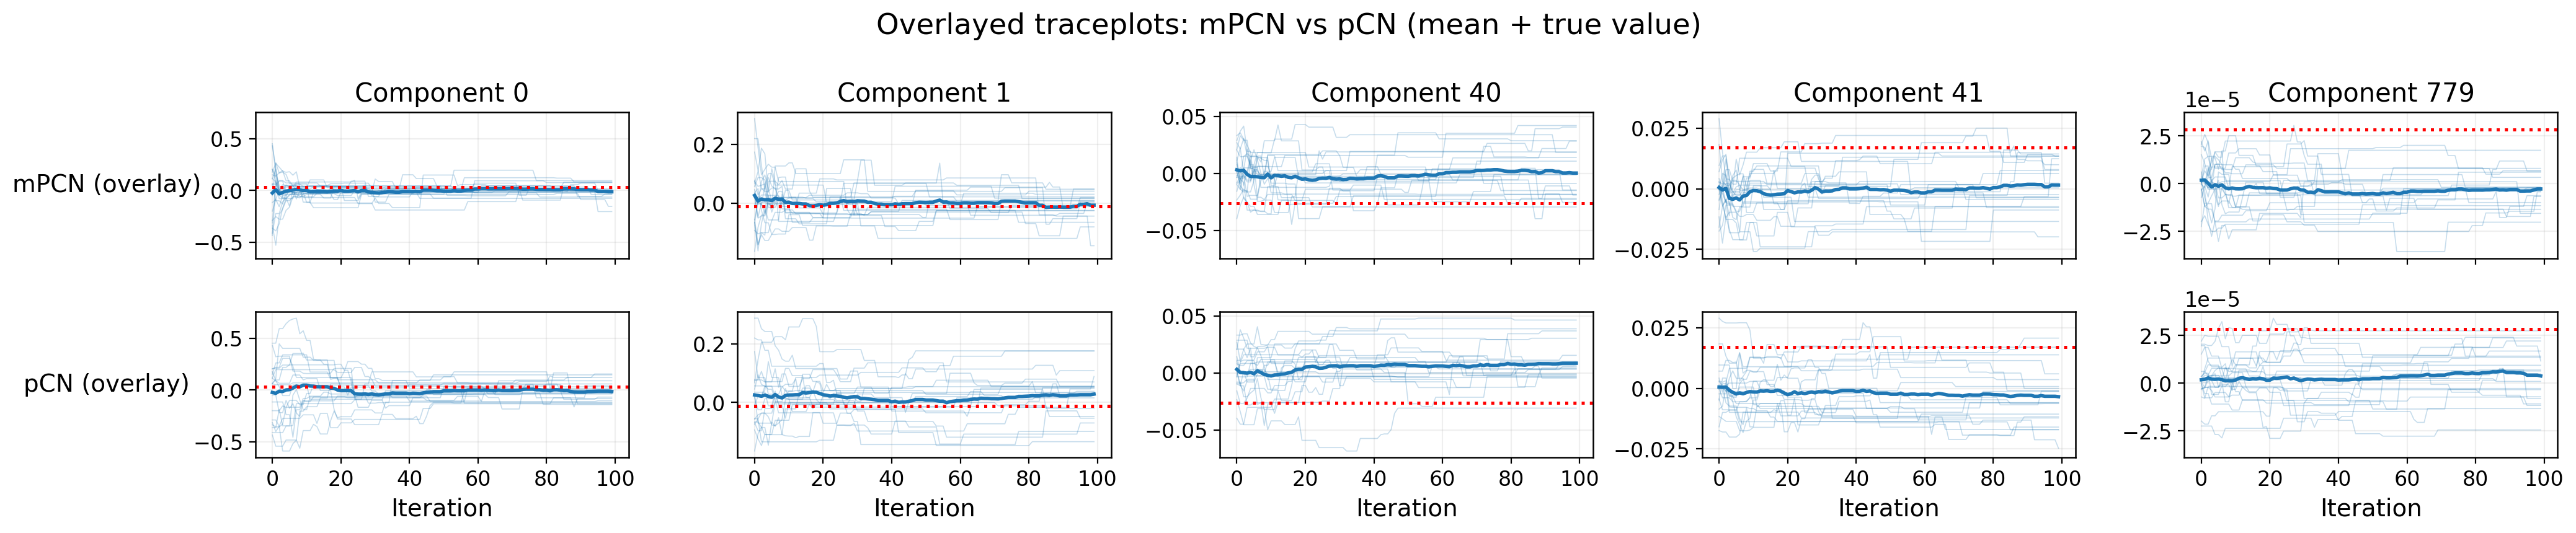

In [16]:
# Overlayed traceplots: all mPCN together and all pCN together
apply_pub_style()

comp_list = [0, 1, 40, 41, 779]
comp_list = [idx for idx in comp_list if idx < problem.dim]
if len(comp_list) < 1:
    raise ValueError('Need at least one component for traceplots.')

plot_n = min(n_iters, 100)
mpcn_plot_count = 50
pcn_plot_count = 100
mpcn_plot_count = min(mpcn_plot_count, len(mpcn_chains))
pcn_plot_count = min(pcn_plot_count, len(pcn_chains))

mpcn_plot_indices = list(range(mpcn_plot_count))
pcn_pick_indices = list(mpcn_start_indices)[:pcn_plot_count]
if len(pcn_pick_indices) < pcn_plot_count:
    pcn_pick_indices = list(range(pcn_plot_count))

true_values = data.get('a_true', None)

mpcn_stack = np.stack([mpcn_chains[i][:plot_n] for i in mpcn_plot_indices], axis=0)
pcn_stack = np.stack([pcn_chains[i][:plot_n] for i in pcn_pick_indices], axis=0)
mpcn_mean = np.mean(mpcn_stack, axis=0)
pcn_mean = np.mean(pcn_stack, axis=0)

nrows = 2
ncols = len(comp_list)
fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4.2 * ncols, 2.2 * nrows),
    sharex=True,
    sharey='col',
)
if ncols == 1:
    axes = axes[:, None]

row_defs = [
    ('mPCN (overlay)', mpcn_stack, mpcn_mean),
    ('pCN (overlay)', pcn_stack, pcn_mean),
 ]

for row_idx, (label, stack, mean_chain) in enumerate(row_defs):
    for col_idx, comp in enumerate(comp_list):
        ax = axes[row_idx, col_idx]
        for chain_idx in range(stack.shape[0]):
            ax.plot(stack[chain_idx, :, comp], linewidth=0.6, color='tab:blue', alpha=0.25)
        ax.plot(mean_chain[:, comp], linewidth=2, color='tab:blue')
        if true_values is not None:
            ax.axhline(
                true_values[comp],
                color='red',
                linestyle=':',
                linewidth=1.8,
            )
        if row_idx == 0:
            ax.set_title(f'Component {comp}')
        if col_idx == 0:
            ax.set_ylabel(label, rotation=0, labelpad=50, va='center')
        ax.grid(alpha=0.2)

for ax in axes[-1, :]:
    ax.set_xlabel('Iteration')

fig.suptitle('Overlayed traceplots: mPCN vs pCN (mean + true value)')
fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_mpcn_vs_pcn_traceplots_overlay_rho{rho_tag}.png',
    bbox_inches='tight',
)
plt.show()

## Autocorrelation of chains

Compute per-component ACF using statsmodels and average across components to get one ACF per chain.
Plots show selected chain ACFs and the average ACF across the first N chains.

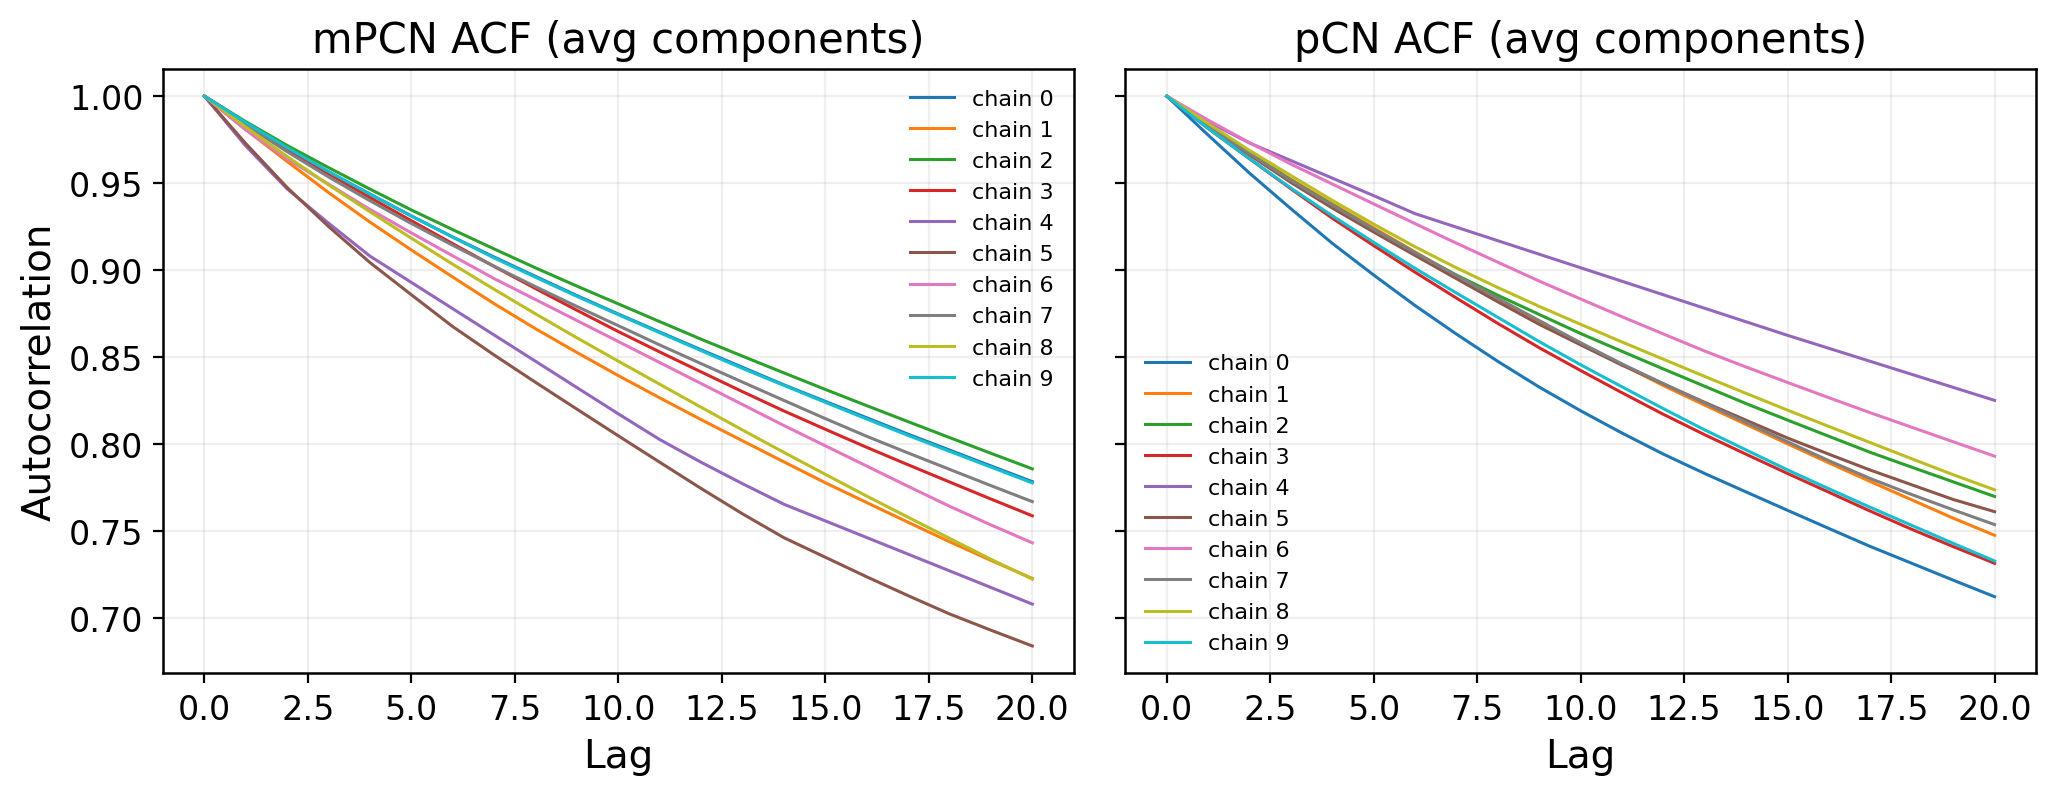

In [ ]:
apply_pub_style()

from statsmodels.tsa.stattools import acf as sm_acf

acf_max_lag = 20
burnin_acf = 200
num_acf_chains = 10
pcn_acf_indices = [x for x in np.arange(num_acf_chains)]
mpcn_acf_indices = [x for x in np.arange(num_acf_chains)]
refresh_acf_metrics = False

acf_metrics_dir = estimations_dir / 'metrics' / 'acf'
acf_metrics_dir.mkdir(parents=True, exist_ok=True)
pcn_acf_path = acf_metrics_dir / f'pcn_acf_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{burnin_acf}.npz'
mpcn_acf_path = acf_metrics_dir / f'mpcn_acf_P{P}_rho{rho_tag}_seed{seed_mcmc}_lag{acf_max_lag}_burn{burnin_acf}.npz'

def chain_acf_avg_components(chain, max_lag, burn_in=0):
    post = chain[burn_in:] if burn_in else chain
    if post.shape[0] < 2:
        acf_vals = np.zeros(max_lag + 1, dtype=float)
        acf_vals[0] = 1.0
        return acf_vals
    acfs = [
        sm_acf(post[:, j], nlags=max_lag, fft=True, adjusted=False)
        for j in range(post.shape[1])
    ]
    return np.mean(np.stack(acfs, axis=0), axis=0)

def _load_acf_matrix(path, chain_count, max_lag, burn_in):
    if not path.exists():
        return None
    data = np.load(path)
    acf_matrix = data.get('acf_matrix')
    if acf_matrix is None:
        return None
    if acf_matrix.shape != (chain_count, max_lag + 1):
        return None
    if int(data.get('burn_in', -1)) != int(burn_in):
        return None
    if int(data.get('max_lag', -1)) != int(max_lag):
        return None
    return acf_matrix

def _save_acf_matrix(path, acf_matrix, max_lag, burn_in):
    np.savez_compressed(
        path,
        acf_matrix=acf_matrix,
        chain_count=int(acf_matrix.shape[0]),
        max_lag=int(max_lag),
        burn_in=int(burn_in),
    )

def _compute_acf_matrix(chains, max_lag, burn_in):
    return np.stack(
        [chain_acf_avg_components(chain, max_lag, burn_in=burn_in) for chain in chains],
        axis=0,
    )

pcn_acf_matrix = None
mpcn_acf_matrix = None
if not refresh_acf_metrics:
    pcn_acf_matrix = _load_acf_matrix(pcn_acf_path, len(pcn_chains), acf_max_lag, burnin_acf)
    mpcn_acf_matrix = _load_acf_matrix(mpcn_acf_path, len(mpcn_chains), acf_max_lag, burnin_acf)
if pcn_acf_matrix is None:
    pcn_acf_matrix = _compute_acf_matrix(pcn_chains, acf_max_lag, burnin_acf)
    _save_acf_matrix(pcn_acf_path, pcn_acf_matrix, acf_max_lag, burnin_acf)
if mpcn_acf_matrix is None:
    mpcn_acf_matrix = _compute_acf_matrix(mpcn_chains, acf_max_lag, burnin_acf)
    _save_acf_matrix(mpcn_acf_path, mpcn_acf_matrix, acf_max_lag, burnin_acf)

mpcn_acf_indices = [i for i in mpcn_acf_indices if 0 <= i < len(mpcn_chains)]
pcn_acf_indices = [i for i in pcn_acf_indices if 0 <= i < len(pcn_chains)]

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.2), sharey=True)
lag_grid = np.arange(acf_max_lag + 1)

for idx in mpcn_acf_indices:
    axes[0].plot(lag_grid, mpcn_acf_matrix[idx], linewidth=1.1, label=f'chain {idx}')
axes[0].set_title('mPCN ACF (avg components)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].grid(alpha=0.2)
if mpcn_acf_indices:
    axes[0].legend(frameon=False, fontsize=8)

for idx in pcn_acf_indices:
    axes[1].plot(lag_grid, pcn_acf_matrix[idx], linewidth=1.1, label=f'chain {idx}')
axes[1].set_title('pCN ACF (avg components)')
axes[1].set_xlabel('Lag')
axes[1].grid(alpha=0.2)
if pcn_acf_indices:
    axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_acf_selected_rho{rho_tag}.png',
    bbox_inches='tight',
 )
plt.show()

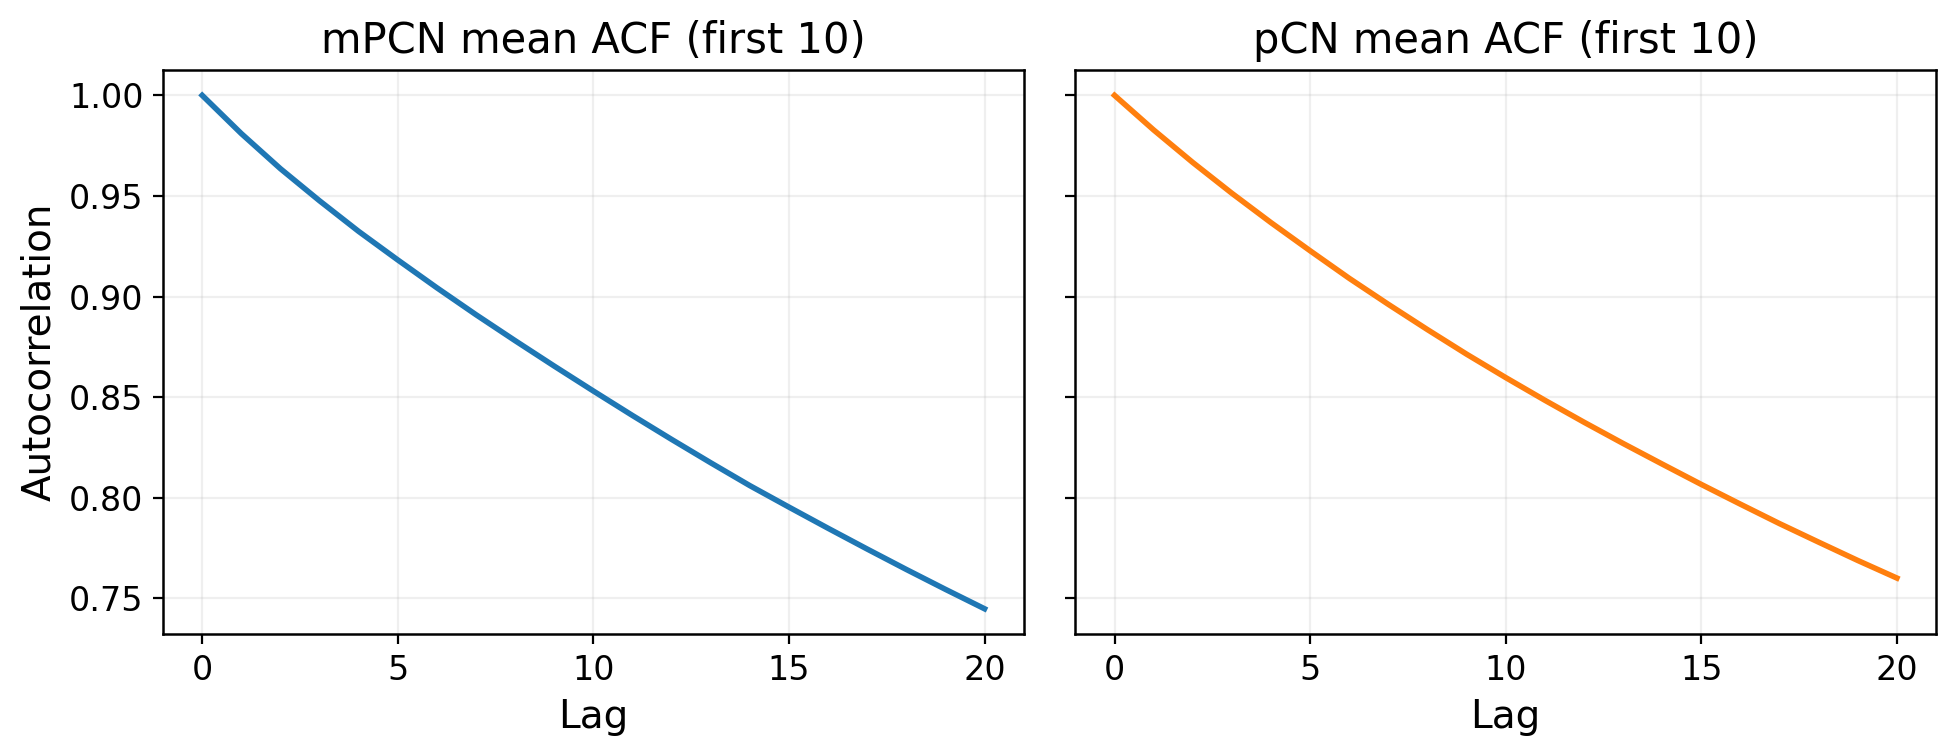

In [ ]:
apply_pub_style()

avg_mpcn_count = num_acf_chains
avg_pcn_count = num_acf_chains

avg_mpcn_count = min(avg_mpcn_count, len(mpcn_chains))
avg_pcn_count = min(avg_pcn_count, len(pcn_chains))

if avg_mpcn_count < 1 or avg_pcn_count < 1:
    raise ValueError('Need at least one chain in each group for averages.')

print('Averaging precomputed ACF metrics from cache.')
mpcn_acf_mean = np.mean(mpcn_acf_matrix[:avg_mpcn_count], axis=0)
pcn_acf_mean = np.mean(pcn_acf_matrix[:avg_pcn_count], axis=0)
lag_grid = np.arange(acf_max_lag + 1)

fig, ax = plt.subplots(1, 1, figsize=(9.0, 4.0))
ax.plot(lag_grid, mpcn_acf_mean, linewidth=2.0, color='tab:blue', label='mPCN mean')
ax.plot(lag_grid, pcn_acf_mean, linewidth=2.0, color='tab:orange', label='pCN mean')
ax.set_title(f'ACF mean (first {avg_mpcn_count} mPCN, {avg_pcn_count} pCN)')
ax.set_xlabel('Lag')
ax.set_ylabel('Autocorrelation')
ax.grid(alpha=0.2)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
fig.savefig(
    reports_dir / f'solute_transport_acf_mean_rho{rho_tag}.png',
    bbox_inches='tight',
 )
plt.show()